In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from PIL import Image
import io
import subprocess
import os

In [20]:
# Set random seed for reproducibility
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [21]:




# Define the path to the data directory
data_path = Path("data")

# Define the path to the image directory
image_path = data_path

# Define the path to the zip file (assumed to be uploaded to Colab's root directory)
zip_file_path = Path("fresh_stale_smtg.zip")

# Check if the zip file exists
if not zip_file_path.is_file():
    raise FileNotFoundError(f"Zip file not found at {zip_file_path}. Please upload 'fresh_stale_smtg.zip' to the Colab environment.")

# Check if the image directory already exists
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Attempt to extract the zip file using the unzip command
try:
    print(f"Extracting {zip_file_path} to {image_path} using unzip...")
    result = subprocess.run(
        ["unzip", "-o", zip_file_path, "-d", image_path],
        capture_output=True,
        text=True,
        check=True
    )
    print(f"Successfully extracted {zip_file_path} to {image_path}.")
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print(f"Error extracting {zip_file_path}: {e.stderr}")
    raise Exception(f"Failed to extract {zip_file_path} with unzip: {e.stderr}")
except Exception as e:
    raise Exception(f"Unexpected error during extraction of {zip_file_path}: {str(e)}")

# Remove the uploaded zip file
try:
    os.remove(zip_file_path)
    print(f"Removed {zip_file_path} after extraction.")
except Exception as e:
    print(f"Warning: Could not remove {zip_file_path}: {str(e)}")

data directory exists.
Extracting fresh_stale_smtg.zip to data using unzip...
Successfully extracted fresh_stale_smtg.zip to data.
Archive:  fresh_stale_smtg.zip
   creating: data/fresh_stale_smtg/
   creating: data/fresh_stale_smtg/test/
   creating: data/fresh_stale_smtg/test/fresh_apple/
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.10.11 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.10.21 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.10.29 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.10.37 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.10.43 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/vertical_flip_Screen Shot 2018-06-08 at 5.11.08 PM.png  
  inflating: data/fresh_stale_smtg/test/fresh_apple/ve

In [22]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT typically uses 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [26]:
# Load datasets
image_path = Path("/content/data/fresh_stale_smtg")
try:
    train_dataset = torchvision.datasets.ImageFolder(
        image_path / "train", transform=train_transform
    )
    test_dataset = torchvision.datasets.ImageFolder(
        image_path / "test", transform=test_transform
    )
except Exception as e:
    raise Exception(f"Error loading dataset from {image_path}: {str(e)}. Ensure 'train' and 'test' folders exist with 'fresh' and 'stale' subfolders.")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [27]:
# Define Vision Transformer components
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.n_patches + 1, embed_dim)
        )

    def forward(self, x):
        # x: (batch_size, channels, img_size, img_size)
        x = self.proj(x)  # (batch_size, embed_dim, n_patches_sqrt, n_patches_sqrt)
        x = x.flatten(2).transpose(1, 2)  # (batch_size, n_patches, embed_dim)
        batch_size = x.shape[0]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (batch_size, n_patches + 1, embed_dim)
        x = x + self.pos_embed
        return x

In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.shape
        qkv = self.qkv(x).reshape(
            batch_size, seq_len, 3, self.num_heads, self.head_dim
        ).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(batch_size, seq_len, embed_dim)
        x = self.proj(x)
        return x

In [29]:
class MLP(nn.Module):
    def __init__(self, embed_dim=768, mlp_dim=3072):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, mlp_dim)
        self.fc2 = nn.Linear(mlp_dim, embed_dim)
        self.gelu = nn.GELU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.fc2(x)
        return x

In [30]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, mlp_dim=3072):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

In [31]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=768,
        num_heads=12,
        mlp_dim=3072,
        num_layers=12,
        num_classes=2
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim)
            for _ in range(num_layers)
        ])
        self.ln = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln(x)
        x = x[:, 0]  # Take the cls token
        x = self.head(x)
        return x

In [32]:
# Initialize model
model = VisionTransformer(
    img_size=224,
    patch_size=16,
    in_channels=3,
    embed_dim=768,
    num_heads=12,
    mlp_dim=3072,
    num_layers=12,
    num_classes=2
).to(device)

In [33]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [34]:
# Training loop
num_epochs = 20
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    scheduler.step()

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


Epoch 1/20, Loss: 4.3186, Test Accuracy: 49.00%
Epoch 2/20, Loss: 2.2234, Test Accuracy: 49.00%
Epoch 3/20, Loss: 0.8437, Test Accuracy: 50.00%
Epoch 4/20, Loss: 0.8447, Test Accuracy: 50.00%
Epoch 5/20, Loss: 0.6969, Test Accuracy: 49.00%
Epoch 6/20, Loss: 0.8661, Test Accuracy: 49.00%
Epoch 7/20, Loss: 0.7802, Test Accuracy: 50.00%
Epoch 8/20, Loss: 0.7042, Test Accuracy: 50.00%
Epoch 9/20, Loss: 0.6835, Test Accuracy: 62.00%
Epoch 10/20, Loss: 0.6676, Test Accuracy: 57.00%
Epoch 11/20, Loss: 0.6773, Test Accuracy: 59.00%
Epoch 12/20, Loss: 0.6715, Test Accuracy: 61.00%
Epoch 13/20, Loss: 0.6634, Test Accuracy: 64.00%
Epoch 14/20, Loss: 0.6578, Test Accuracy: 63.00%
Epoch 15/20, Loss: 0.6499, Test Accuracy: 58.00%
Epoch 16/20, Loss: 0.6509, Test Accuracy: 56.00%
Epoch 17/20, Loss: 0.6512, Test Accuracy: 47.00%
Epoch 18/20, Loss: 0.6525, Test Accuracy: 54.00%
Epoch 19/20, Loss: 0.6503, Test Accuracy: 54.00%
Epoch 20/20, Loss: 0.6524, Test Accuracy: 55.00%


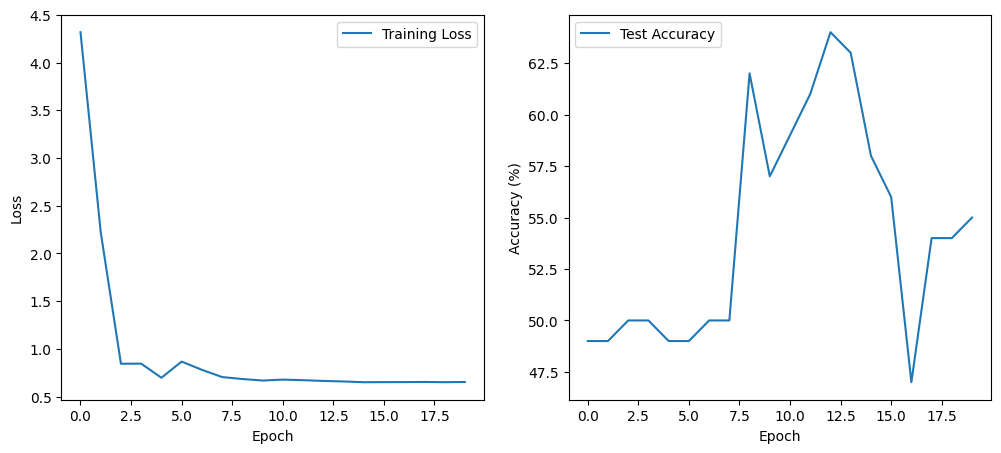

In [35]:
# Plot training loss and test accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


In [36]:
# Save the model
torch.save(model.state_dict(), "vit_fresh_stale_apple.pth")
print("Model saved as vit_fresh_stale_apple.pth")


Model saved as vit_fresh_stale_apple.pth



Upload an image to predict whether the apple is fresh or stale:


Saving download.jpg to download.jpg


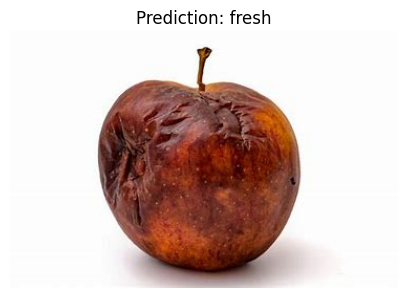

The apple in the image is predicted to be: fresh


In [37]:
# Image upload and prediction
print("\nUpload an image to predict whether the apple is fresh or stale:")
uploaded = files.upload()

# Process the uploaded image
try:
    # Get the first uploaded file
    file_name = list(uploaded.keys())[0]
    img_data = uploaded[file_name]

    # Open and process the image
    img = Image.open(io.BytesIO(img_data)).convert("RGB")

    # Apply the same transform as test set
    img_tensor = test_transform(img).unsqueeze(0).to(device)

    # Load the saved model
    model.load_state_dict(torch.load("vit_fresh_stale_apple.pth"))
    model.eval()

    # Make prediction
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
        class_names = ["fresh", "stale"]
        prediction = class_names[predicted.item()]

    # Display the image and prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()
    print(f"The apple in the image is predicted to be: {prediction}")

except Exception as e:
    print(f"Error processing the uploaded image: {str(e)}")
    print("Please ensure you uploaded a valid image file (e.g., JPEG, PNG) and try again.")